In [ ]:
import sys
from pathlib import Path
%matplotlib inline
PROJECT_ROOT = Path(r"F:\COURS IA\3A\P2 courses\REINFORFCEMENT LEARNING\rl-trading-agent")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

OUTPUT_DIR = PROJECT_ROOT / "application" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

from environment.setup_env import build_envs
from agents.DRL import DRLAgent
from agents.architectures import SimplePortfolioMLP

train_env, test_env, train_df, test_df = build_envs()
print(type(train_env))
print(f"Train rows: {len(train_df)} | Test rows: {len(test_df)}")

1. Downloading data


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Shape of DataFrame:  (4527, 8)
2. Adding technical indicators
Successfully added technical indicators
3. Computing rolling covariance
4. Splitting train / test
Train : 2019-01-03 → 2021-12-31 (2268 rows)
Test  : 2022-01-03 → 2023-12-29 (1503 rows)
5. Creating environments
Done
<class 'environment.portfolio_env.StockPortfolioEnv'>
Train rows: 2268 | Test rows: 1503


In [2]:
agent = DRLAgent(env=train_env)

pg_model = agent.get_model(
    "pg",
    policy=SimplePortfolioMLP,
    device="cpu",
    model_kwargs={
        "batch_size": 64,
        "lr": 1e-3,
        "action_noise": 0.01,
    },
    policy_kwargs={
        "input_shape": (7, 3),
        "portfolio_size": 3,
        "hidden_dim": 64,
        "device": "cpu",
    },
)

trained_pg = agent.train_model(pg_model, episodes=5)
trained_pg

Training PG:  20%|██        | 1/5 [00:01<00:06,  1.62s/it, reward=118303426.1109, loss=-0.002446, pv=244429.01, steps=756]

begin_total_asset:100000
end_total_asset:244429.0123005884
Sharpe:  1.1548787742066111


Training PG:  40%|████      | 2/5 [00:02<00:04,  1.47s/it, reward=130472213.5293, loss=-0.003377, pv=279140.87, steps=756]

begin_total_asset:100000
end_total_asset:279140.8737293927
Sharpe:  1.3227230363478715


Training PG:  60%|██████    | 3/5 [00:04<00:02,  1.40s/it, reward=142169924.6836, loss=-0.003423, pv=307822.98, steps=756]

begin_total_asset:100000
end_total_asset:307822.9815730431
Sharpe:  1.4548418487980315


Training PG:  80%|████████  | 4/5 [00:05<00:01,  1.45s/it, reward=143205438.3611, loss=-0.003429, pv=309653.60, steps=756]

begin_total_asset:100000
end_total_asset:309653.6033540157
Sharpe:  1.466034387001113


Training PG: 100%|██████████| 5/5 [00:07<00:00,  1.43s/it, reward=143476301.8461, loss=-0.003429, pv=310144.83, steps=756]

begin_total_asset:100000
end_total_asset:310144.82547900616
Sharpe:  1.4682647411723149


In [3]:
results_pg, actions_pg = DRLAgent.DRL_prediction(
    model=trained_pg,
    environment=test_env,
    online_training_period=10**9,
    lr=0,
)

results_path = OUTPUT_DIR / "results_pg.csv"
actions_path = OUTPUT_DIR / "actions_pg.csv"

results_pg.to_csv(results_path, index=False)
actions_pg.to_csv(actions_path, index=False)

print(f"Saved results to: {results_path}")
print(f"Saved actions to: {actions_path}")

print(results_pg.head())
print(actions_pg.head())

begin_total_asset:100000
end_total_asset:122654.69167313159
Sharpe:  0.5684755496820415
Saved results to: F:\COURS IA\3A\P2 courses\REINFORFCEMENT LEARNING\rl-trading-agent\application\outputs\results_pg.csv
Saved actions to: F:\COURS IA\3A\P2 courses\REINFORFCEMENT LEARNING\rl-trading-agent\application\outputs\actions_pg.csv
        date  portfolio_value  daily_return
0 2022-01-03    100000.000000      0.000000
1 2022-01-04    100869.470411      0.008695
2 2022-01-05     99198.742329     -0.016563
3 2022-01-06     98962.576113     -0.002381
4 2022-01-07     99398.677687      0.004407
        date      AAPL       JPM       XOM
0 2022-01-03  0.333333  0.333333  0.333333
1 2022-01-04  0.576117  0.211942  0.211942
2 2022-01-05  0.576117  0.211942  0.211942
3 2022-01-06  0.576117  0.211942  0.211942
4 2022-01-07  0.576117  0.211942  0.211942


C:\Users\dehay\AppData\Local\Temp\ipykernel_82100\2872587865.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


,date,AAPL,JPM,XOM
0,2022-01-03,0.333333,0.333333,0.333333
1,2022-01-04,0.576117,0.211942,0.211942
2,2022-01-05,0.576117,0.211942,0.211942
3,2022-01-06,0.576117,0.211942,0.211942
4,2022-01-07,0.576117,0.211942,0.211942


F:\COURS IA\3A\P2 courses\REINFORFCEMENT LEARNING\rl-trading-agent\application\results\cumulative_reward.png


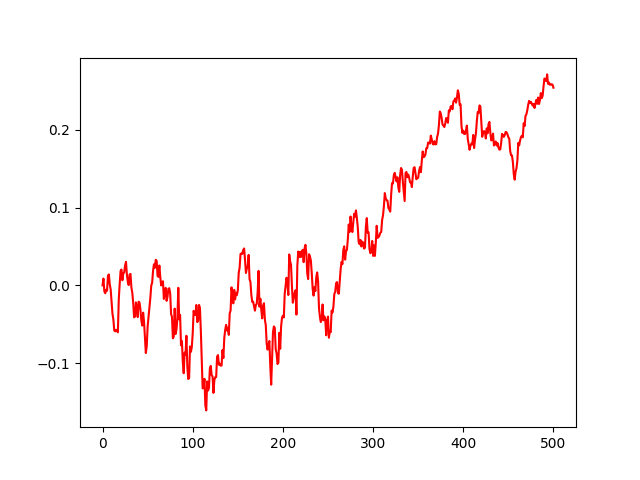

F:\COURS IA\3A\P2 courses\REINFORFCEMENT LEARNING\rl-trading-agent\application\results\rewards.png


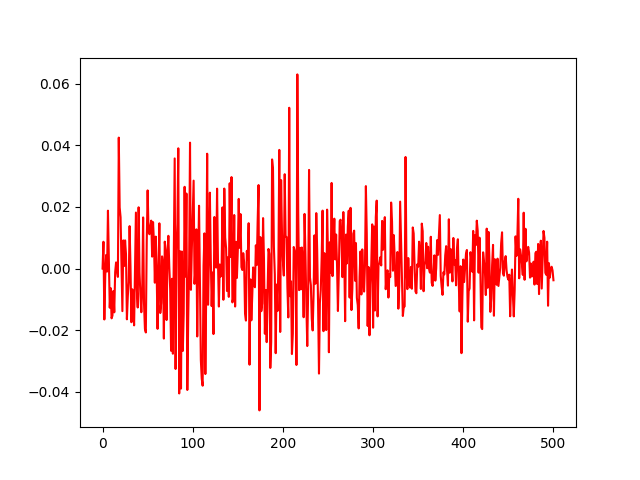

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

results_df = pd.read_csv(results_path)
actions_df = pd.read_csv(actions_path)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
results_df.plot(x="date", y="portfolio_value", ax=axes[0], legend=False, title="Portfolio value on test set")
results_df.plot(x="date", y="daily_return", ax=axes[1], legend=False, title="Daily return on test set")
plt.tight_layout()
plt.show()

display(actions_df.head())

saved_plots = list((PROJECT_ROOT / "application").rglob("*.png")) + list(PROJECT_ROOT.rglob("cumulative_reward.png")) + list(PROJECT_ROOT.rglob("rewards.png"))
for plot_path in sorted({path.resolve() for path in saved_plots}):
    print(plot_path)
    display(Image(filename=str(plot_path)))

In [3]:
from run_comparison import run_comparison

artifacts = run_comparison(
    if_using_exp3=True,
    if_using_reinforce=False,
    if_using_dqn=False,
    if_using_policy_gradient=True,
    if_using_ppo=False,
    reward_type="portfolio_return",  # ou "portfolio_value" / "log_return"
)

summary_df = artifacts["summary"]
comparison_df = artifacts["comparison"]

print("Output dir:", artifacts["output_dir"])
display(summary_df)
comparison_df.head()

[*********************100%***********************]  1 of 1 completed

1. Downloading data



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Shape of DataFrame:  (4527, 8)
2. Adding technical indicators
Successfully added technical indicators
3. Computing rolling covariance
4. Splitting train / test
Train : 2019-01-03 → 2021-12-31 (2268 rows)
Test  : 2022-01-03 → 2023-12-29 (1503 rows)
5. Creating environments
Done
<class 'environment.portfolio_env.StockPortfolioEnv'>
[run] PolicyGradient


Training PG:   2%|▏         | 1/50 [00:04<04:00,  4.90s/it, reward=1.2150, loss=-0.003431, pv=298596.19, steps=756]

...

Training PG: 100%|██████████| 50/50 [02:34<00:00,  3.08s/it, reward=1.3270, loss=-0.003430, pv=333086.23, steps=756]

begin_total_asset:100000
end_total_asset:333086.23358361505
Sharpe:  1.5447231095077234


begin_total_asset:100000
end_total_asset:123063.72537760103
Sharpe:  0.5760624339057028
[run] Exp3
begin_total_asset:100000
end_total_asset:207755.114750846
Sharpe:  0.860612096952158
[Exp3] Episode 1/5 — final portfolio value : 0.01 — weights : [444.9938 950.8584 909.9214]
begin_total_asset:100000
end_total_asset:218626.69014865623
Sharpe:  0.9217544226233751
[Exp3] Episode 2/5 — final portfolio value : -0.00 — weights : [297763.4199  53970.2638 885008.8276]
begin_total_asset:100000
end_total_asset:157537.1722876368
Sharpe:  0.6146002634318671
[Exp3] Episode 3/5 — final portfolio value : 0.01 — weights : [1.02243194e+08 3.51494679e+07 6.01956382e+08]
begin_total_asset:100000
end_total_asset:166042.43503194826
Sharpe:  0.6400100952305958
[Exp3] Episode 4/5 — final portfolio value : 0.01 — weights : [2.40009341e+09 1.05894571e+11 1.00441795e+12]
begin_total_asset:100000
end_total_asset:134362.53065203037
Sharpe:  0.4505528749645001
[Exp3] Episode 5/5 — final portfolio value : 0.01 — wei

,model,reward_type,initial_portfolio_value,final_portfolio_value,total_return,sharpe,num_steps
1,exp3,portfolio_return,100000.0,170451.510372,0.704515,1.028908,500
0,policy_gradient,portfolio_return,100000.0,123063.725378,0.230637,0.576062,500


,date,portfolio_value,daily_return,reward,model,reward_type
0,2022-01-03,100000.000000,0.000000,0.000000,policy_gradient,portfolio_return
1,2022-01-04,100869.478292,0.008695,0.008695,policy_gradient,portfolio_return
2,2022-01-05,99198.743007,-0.016563,-0.016563,policy_gradient,portfolio_return
3,2022-01-06,98962.584871,-0.002381,-0.002381,policy_gradient,portfolio_return
4,2022-01-07,99398.669941,0.004407,0.004407,policy_gradient,portfolio_return


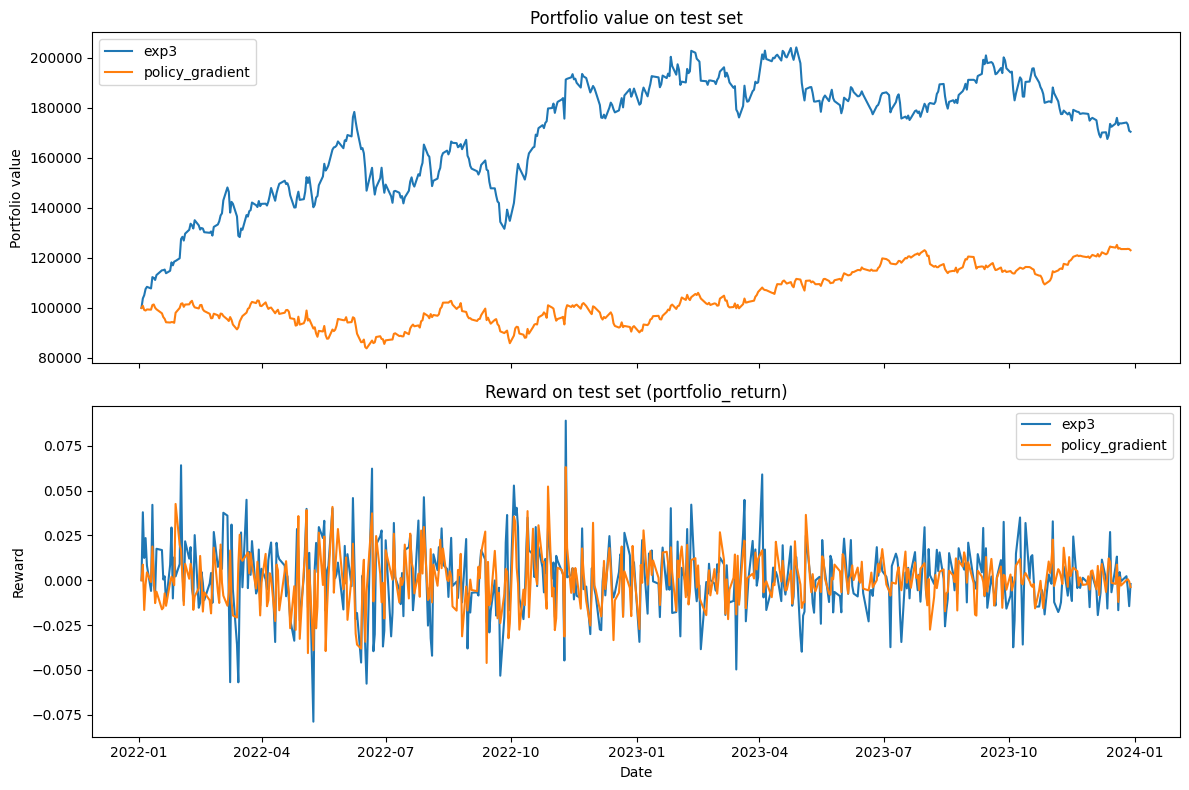

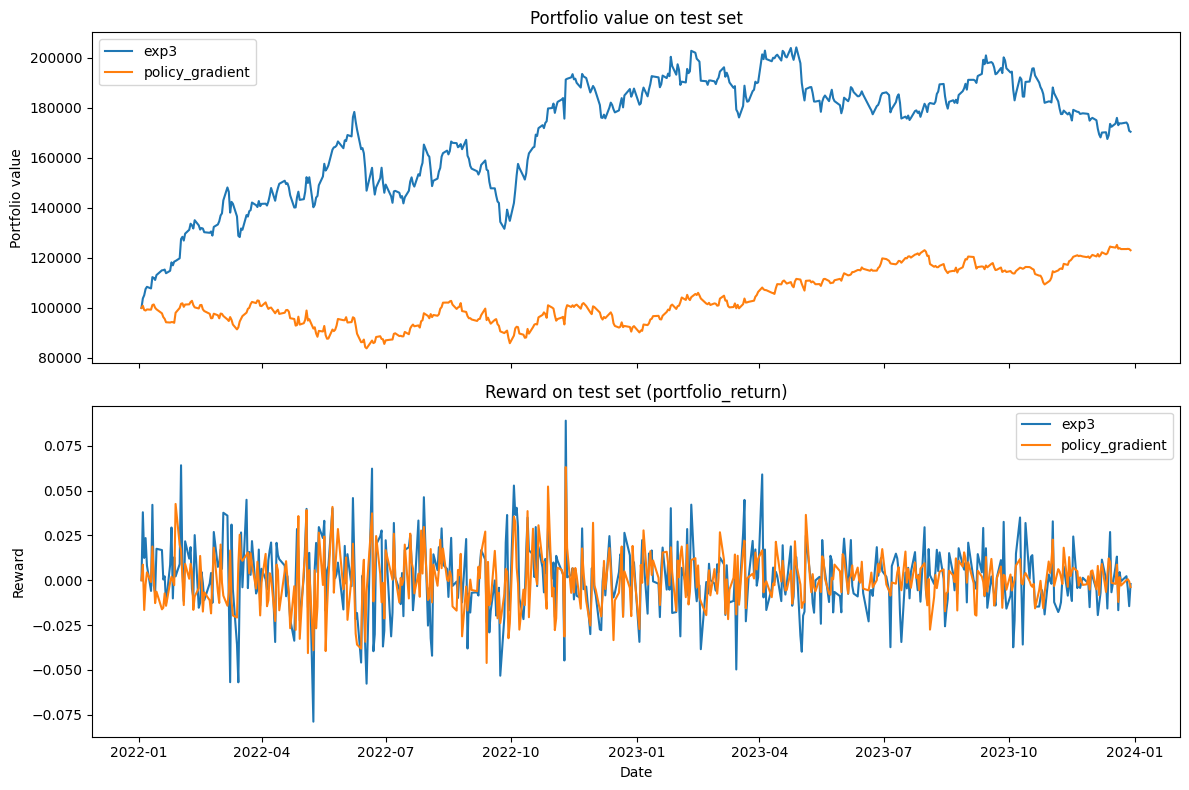

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for model_name, model_df in comparison_df.groupby("model"):
    model_df = model_df.sort_values("date")
    axes[0].plot(model_df["date"], model_df["portfolio_value"], label=model_name)
    axes[1].plot(model_df["date"], model_df["reward"], label=model_name)

axes[0].set_title("Portfolio value on test set")
axes[0].set_ylabel("Portfolio value")
axes[0].legend()

axes[1].set_title(f"Reward on test set ({artifacts['reward_type']})")
axes[1].set_ylabel("Reward")
axes[1].set_xlabel("Date")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
%matplotlib inline